In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load the dataset
df = pd.read_csv('train.csv')

In [12]:
print("Shape: ", df.shape)

df.info()

df.head()

df.describe(include='all')

Shape:  (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': ((df.isnull().sum() / len(df)) * 100).round(2)
})

print(missing_data)

             Missing Values  Percentage
PassengerId               0        0.00
Survived                  0        0.00
Pclass                    0        0.00
Name                      0        0.00
Sex                       0        0.00
Age                     177       19.87
SibSp                     0        0.00
Parch                     0        0.00
Ticket                    0        0.00
Fare                      0        0.00
Cabin                   687       77.10
Embarked                  2        0.22


<Axes: >

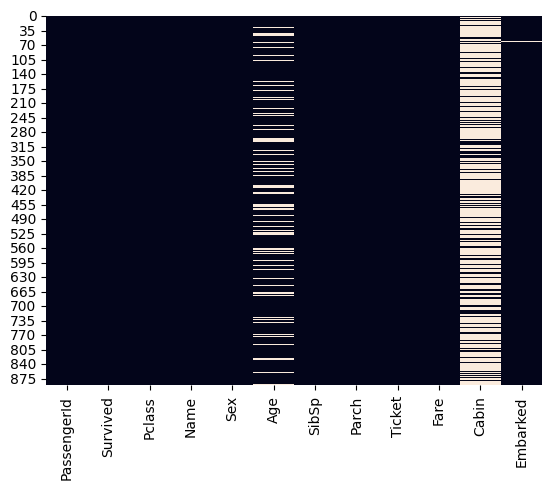

In [7]:
sns.heatmap(df.isnull(), cbar=False)

| Column   | Missing % | Decision      |
| -------- | --------- | ------------- |
| Age      | ~20%      | fill values   |
| Cabin    | ~77%      | probably drop |
| Embarked | ~0.2%     | easy to fill  |

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop('Cabin', axis=1, inplace=True)

KeyError: "['Cabin'] not found in axis"

In [10]:
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': ((df.isnull().sum() / len(df)) * 100).round(2)
})

print(missing_data)

             Missing Values  Percentage
PassengerId               0         0.0
Survived                  0         0.0
Pclass                    0         0.0
Name                      0         0.0
Sex                       0         0.0
Age                       0         0.0
SibSp                     0         0.0
Parch                     0         0.0
Ticket                    0         0.0
Fare                      0         0.0
Embarked                  0         0.0


<Axes: >

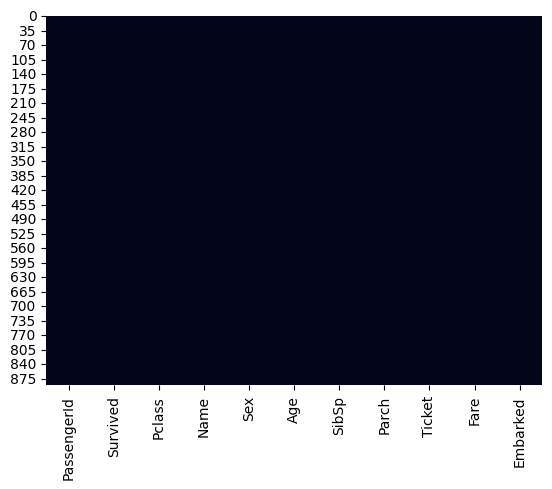

In [11]:
sns.heatmap(df.isnull(), cbar=False)

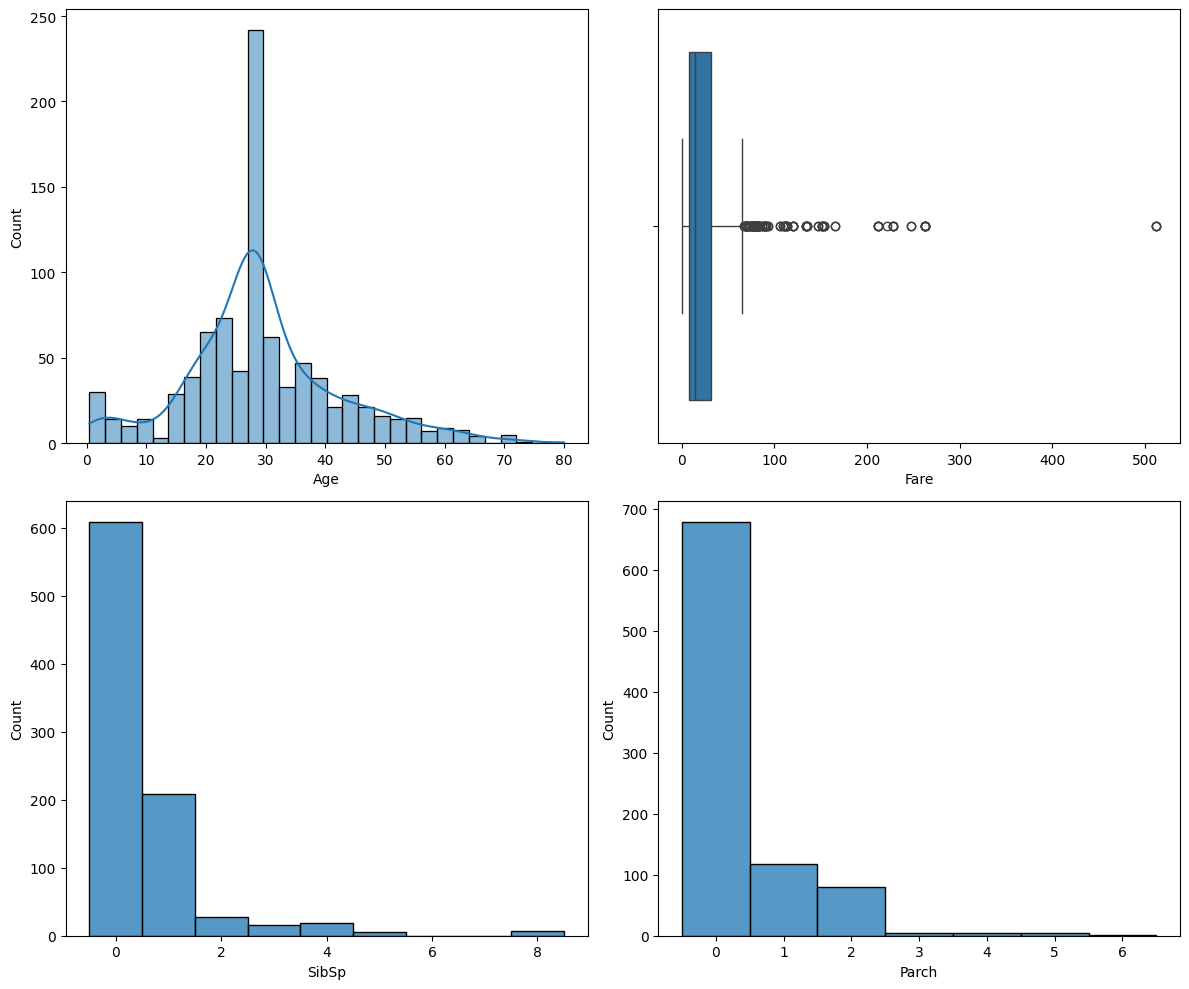

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df['Age'], kde=True, ax=axes[0,0])
sns.boxplot(x=df['Fare'], ax=axes[0,1])
sns.histplot(df['SibSp'], discrete=True, ax=axes[1,0])   # discrete values
sns.histplot(df['Parch'], discrete=True, ax=axes[1,1])
plt.tight_layout()

plt.show()

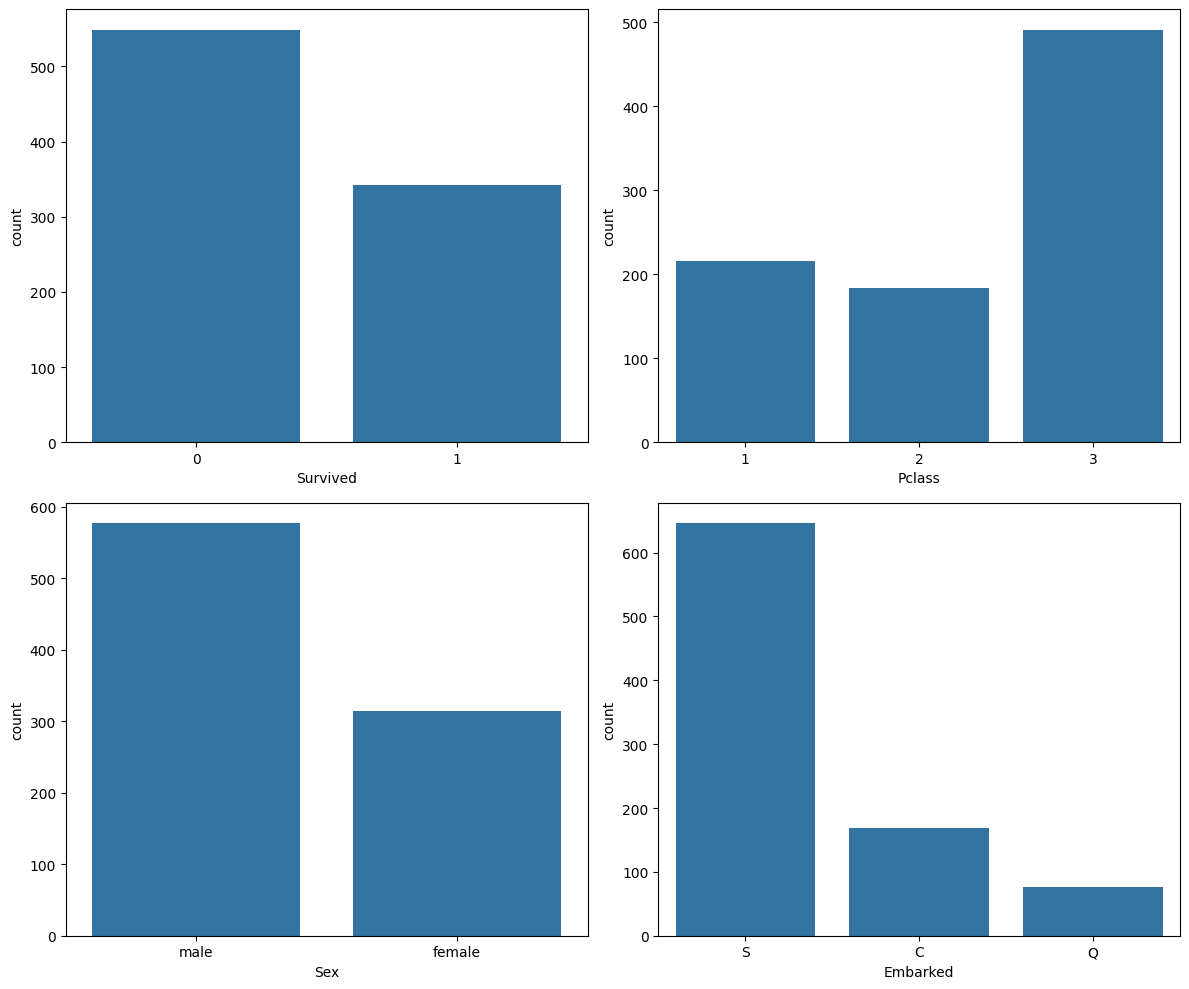

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.countplot(x='Survived', data=df, ax=axes[0,0])
sns.countplot(x='Pclass', data=df, ax=axes[0,1])
sns.countplot(x='Sex', data=df, ax=axes[1,0])
sns.countplot(x='Embarked', data=df, ax=axes[1,1])
plt.tight_layout()
plt.show()